# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

Notebook ini mendokumentasikan tahapan proyek data science untuk membantu Jaya Jaya Institut memonitor dan memprediksi risiko dropout mahasiswa.

## Import Library dan Load Data

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

In [2]:
DATA_PATH = Path('data/students_performance.csv')
df = pd.read_csv(DATA_PATH, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()
df['Status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

## Business Understanding

Jaya Jaya Institut perlu menekan dropout dengan mendeteksi mahasiswa berisiko sejak dini. Target analisis adalah memahami faktor dropout dan membuat prototype machine learning untuk prediksi risiko.

## Persiapan Proyek

Sumber data yang digunakan adalah `data/students_performance.csv`. Dataset berasal dari student performance dataset pada UCI Machine Learning Repository dan disediakan pada kelas Dicoding. Proyek dapat dijalankan dengan membuat virtual environment, menginstal `requirements.txt`, menjalankan seluruh cell notebook, lalu menjalankan prototype menggunakan `streamlit run app.py`.

## Data Preparation

Untuk pemodelan, data difilter hanya pada status `Dropout` dan `Graduate`. Status `Enrolled` tidak digunakan dalam training karena status akhirnya belum diketahui. Target biner `is_dropout` dibuat dengan label 1 untuk `Dropout` dan 0 untuk `Graduate`. Data `Enrolled` tetap disimpan sebagai data inferensi pada prototype.

In [4]:
df_completed = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
df_completed['is_dropout'] = (df_completed['Status'] == 'Dropout').astype(int)
X = df_completed.drop(columns=['Status', 'is_dropout'])
y = df_completed['is_dropout']
print('Jumlah data training:', len(df_completed))
print('Data Enrolled yang dikeluarkan dari training:', int((df['Status'] == 'Enrolled').sum()))
print(y.value_counts())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

Jumlah data training: 3630
Data Enrolled yang dikeluarkan dari training: 794
is_dropout
0    2209
1    1421
Name: count, dtype: int64


((2904, 36), (726, 36))

## Exploratory Data Analysis

In [5]:
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'count']
status_counts

,Status,count
0,Graduate,2209
1,Dropout,1421
2,Enrolled,794


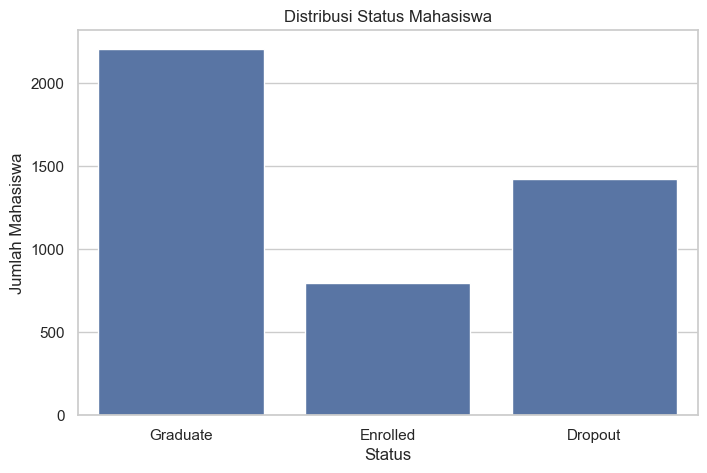

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', order=['Graduate', 'Enrolled', 'Dropout'])
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

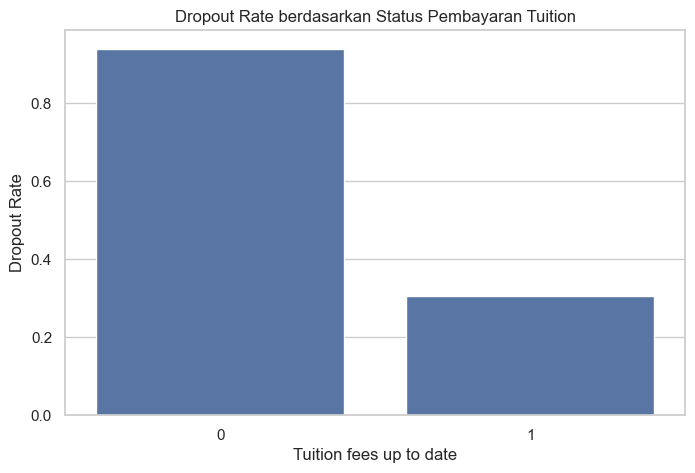

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_completed, x='Tuition_fees_up_to_date', y='is_dropout', estimator=np.mean, errorbar=None)
plt.title('Dropout Rate berdasarkan Status Pembayaran Tuition')
plt.xlabel('Tuition fees up to date')
plt.ylabel('Dropout Rate')
plt.show()

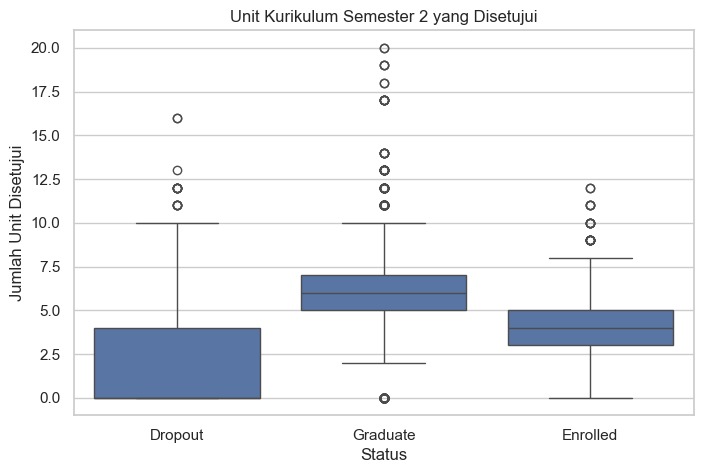

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved')
plt.title('Unit Kurikulum Semester 2 yang Disetujui')
plt.xlabel('Status')
plt.ylabel('Jumlah Unit Disetujui')
plt.show()

## Modeling

Model yang digunakan adalah Random Forest dengan class weight balanced untuk membantu menangani ketidakseimbangan target. Model dilatih sebagai klasifikasi biner Dropout vs Graduate.

In [9]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=250, max_depth=12, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       442
           1       0.91      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



In [10]:
metrics = {
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1': float(f1_score(y_test, y_pred)),
}
metrics

{'accuracy': 0.9201101928374655,
 'precision': 0.9124087591240876,
 'recall': 0.8802816901408451,
 'f1': 0.8960573476702509}

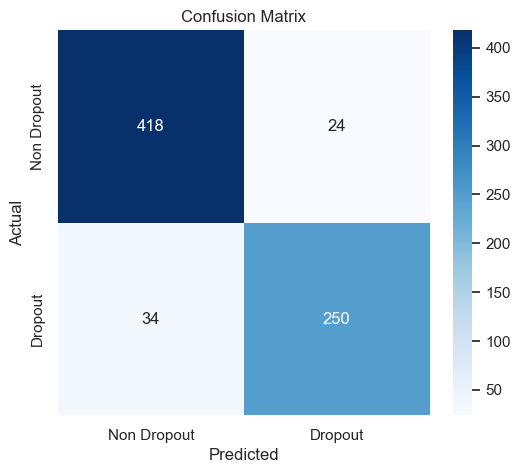

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Dropout', 'Dropout'], yticklabels=['Non Dropout', 'Dropout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)
feature_importance.head(10)

,feature,importance
0,Curricular_units_2nd_sem_approved,0.243031
1,Curricular_units_1st_sem_approved,0.140049
2,Curricular_units_2nd_sem_grade,0.124403
3,Curricular_units_1st_sem_grade,0.073592
4,Tuition_fees_up_to_date,0.056357
5,Curricular_units_2nd_sem_evaluations,0.031249
6,Age_at_enrollment,0.029874
7,Scholarship_holder,0.027965
8,Curricular_units_1st_sem_evaluations,0.025507
9,Course,0.023840


## Deployment Preparation

Model disimpan dalam format joblib dan digunakan oleh prototype Streamlit pada `app.py`.

In [13]:
Path('model').mkdir(exist_ok=True)
metadata = {
    **metrics,
    'features': list(X.columns),
    'threshold': 0.5,
    'training_statuses': ['Dropout', 'Graduate'],
    'excluded_from_training': {'Enrolled': int((df['Status'] == 'Enrolled').sum())},
    'training_rows': int(len(df_completed)),
    'test_rows': int(len(X_test)),
    'target_distribution': {str(k): int(v) for k, v in y.value_counts().to_dict().items()},
    'top_features': feature_importance.head(10).to_dict(orient='records'),
}
joblib.dump(model, 'model/dropout_prediction_model.joblib')
with open('model/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print('Model dan metadata berhasil disimpan.')

Model dan metadata berhasil disimpan.


## Conclusion

Dari EDA dan dashboard, mahasiswa dropout cenderung memiliki performa akademik semester awal yang lebih rendah, terutama pada jumlah unit kurikulum yang disetujui dan nilai semester. Status pembayaran tuition, status debtor, scholarship holder, dan usia saat pendaftaran juga perlu dipantau. Dari sisi model, Random Forest dilatih hanya dengan data Dropout dan Graduate sehingga target tidak ambigu. Model digunakan sebagai alat bantu prioritas intervensi, bukan sebagai satu-satunya dasar keputusan.

## Action Items

1. Buat daftar prioritas bimbingan berdasarkan probabilitas dropout.
2. Pantau tunggakan pembayaran dan status debtor secara rutin.
3. Berikan pendampingan akademik untuk mahasiswa dengan unit approved rendah.
4. Review dashboard performa mahasiswa secara bulanan.
5. Retrain model saat data akademik periode baru tersedia.